# FASE 6B: Optimización Hiperparamétrica y Comparación de Modelos

**Objetivo:** Mejorar el rendimiento del modelo base (Random Forest) mediante optimización hiperparamétrica, y compararlo contra XGBoost.

**Diagnóstico del modelo base:**
- Clase 0 (Sin Riesgo): F1 = 0.836 ✅ Excelente
- Clase 1 (Prediabetes): F1 = 0.497 ⚠️ **Punto débil — objetivo principal de mejora**
- Clase 2 (Diabetes): F1 = 0.729 ✅ Sólido

**Estrategia:**
1. Optimización del Random Forest con `RandomizedSearchCV`
2. Entrenamiento y optimización de XGBoost
3. Comparación final de ambos modelos
4. Selección del mejor modelo

---
## 1. Imports y Carga de Datos

In [1]:
%load_ext kedro.ipython

[06/15/26 19:10:43] INFO     Using                                                                  ]8;id=541720;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\framework\project\__init__.py\__init__.py]8;;\:]8;id=664681;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\framework\project\__init__.py#269\269]8;;\
                             'c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packa                
                             ges\kedro\framework\project\rich_logging.yml' as logging                              
                             configuration.                                                                        

                    INFO     Registered line magic '%reload_kedro'                                   ]8;id=352771;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=970902;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py#64\64]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=917177;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=794065;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py#66\66]8;;\

                    INFO     Resolved project path as:                                              ]8;id=679755;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=986600;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py#181\181]8;;\
                             c:\Users\alarc\OneDrive\Escritorio\Proyecto_Nhanes_Kedro\proyecto_nhan                
                             es_kedro.                                                                             
                             To set a different path, run '%reload_kedro <project_root>'                           

[06/15/26 19:10:46] INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=950400;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=771957;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro_telemetry\plugin.py#242\242]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

                    INFO     Kedro project Proyecto NHANES Kedro                                    ]8;id=177442;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=100458;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py#147\147]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=774478;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=647734;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py#148\148]8;;\
                             'pipelines'                                                                           

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Scikit-Learn
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    make_scorer,
)

# XGBoost
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
RANDOM_STATE = 42
TARGET_COL = 'DIABETES_RISK'
LABELS_MAP = {0: 'Sin Riesgo', 1: 'Prediabetes', 2: 'Diabetes'}
TARGET_NAMES = ['Sin Riesgo (0)', 'Prediabetes (1)', 'Diabetes (2)']

print('Imports cargados correctamente.')

Imports cargados correctamente.


In [3]:
# Cargar dataset
df = catalog.load('df_master')
print(f'Shape: {df.shape}')

# Separar X / y
exclude_cols = ['SEQN', TARGET_COL]
feature_cols = [c for c in df.columns if c not in exclude_cols]
X = df[feature_cols].copy()
y = df[TARGET_COL].copy()

# Identificar tipos de columnas
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f'Features: {X.shape[1]} ({len(numeric_cols)} numéricas, {len(categorical_cols)} categóricas)')
print(f'Target: {y.shape[0]} registros')

# Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'\nTrain: {X_train.shape[0]} | Test: {X_test.shape[0]}')
for val, count in y_train.value_counts().sort_index().items():
    print(f'  Train Clase {val}: {count:,} ({count/len(y_train)*100:.1f}%)')

[06/15/26 19:10:57] INFO     Loading data from df_master (ParquetDataset)...                   ]8;id=638386;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=199210;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\

Shape: (6045, 709)
Features: 707 (630 numéricas, 77 categóricas)
Target: 6045 registros

Train: 4836 | Test: 1209
  Train Clase 0: 2,927 (60.5%)
  Train Clase 1: 1,308 (27.0%)
  Train Clase 2: 601 (12.4%)


---
## 2. Funciones Auxiliares

In [4]:
def build_preprocessor(numeric_cols, categorical_cols):
    """Construye el ColumnTransformer de preprocesamiento."""
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    transformers_list = [('num', numeric_transformer, numeric_cols)]
    
    if categorical_cols:
        categorical_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
        ])
        transformers_list.append(('cat', categorical_transformer, categorical_cols))
    
    return ColumnTransformer(transformers=transformers_list, remainder='drop')


def evaluate_model(model, X_test, y_test, model_name='Modelo'):
    """Evalúa un modelo y retorna métricas clave."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    
    f1_mac = f1_score(y_test, y_pred, average='macro')
    f1_w = f1_score(y_test, y_pred, average='weighted')
    
    print(f'\n{"=" * 65}')
    print(f'EVALUACIÓN: {model_name}')
    print(f'{"=" * 65}')
    report = classification_report(y_test, y_pred, target_names=TARGET_NAMES, digits=3)
    print(report)
    print(f'F1 Macro:    {f1_mac:.4f}')
    print(f'F1 Weighted: {f1_w:.4f}')
    
    return {
        'name': model_name,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'f1_macro': f1_mac,
        'f1_weighted': f1_w,
        'report': report,
        'cm': confusion_matrix(y_test, y_pred),
    }


def plot_confusion_matrices(results_list, y_test):
    """Plotea matrices de confusión lado a lado para comparar modelos."""
    n = len(results_list)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 5))
    if n == 1:
        axes = [axes]
    
    for ax, res in zip(axes, results_list):
        cm_norm = res['cm'].astype('float') / res['cm'].sum(axis=1)[:, np.newaxis]
        disp = ConfusionMatrixDisplay(cm_norm, display_labels=TARGET_NAMES)
        disp.plot(ax=ax, cmap='Blues', values_format='.2%')
        ax.set_title(f"{res['name']}\nF1 Macro: {res['f1_macro']:.4f}", fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()


print('Funciones auxiliares definidas.')

Funciones auxiliares definidas.


---
## 3. Optimización del Random Forest con RandomizedSearchCV

Buscamos la mejor combinación de hiperparámetros usando muestreo aleatorio sobre un espacio amplio. La métrica de optimización es **F1 Macro** para forzar al modelo a mejorar en **todas** las clases, especialmente la clase 1 (Prediabetes).

In [5]:
# Preprocesador reutilizable
preprocessor = build_preprocessor(numeric_cols, categorical_cols)

# Espacio de búsqueda para Random Forest
rf_param_distributions = {
    'classifier__n_estimators': [100, 200, 300, 500, 700],
    'classifier__max_depth': [5, 10, 15, 20, 30, None],
    'classifier__min_samples_split': [2, 5, 10, 15],
    'classifier__min_samples_leaf': [1, 2, 4, 8],
    'classifier__max_features': ['sqrt', 'log2', 0.3, 0.5],
    'classifier__class_weight': ['balanced', 'balanced_subsample'],
}

# Pipeline base
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# RandomizedSearchCV
rf_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=rf_param_distributions,
    n_iter=40,
    scoring='f1_macro',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=False,
)

print('Iniciando búsqueda de hiperparámetros para Random Forest...')
print(f'Combinaciones a probar: 40')
print(f'Total de fits: 40 × 5 folds = 200')

Iniciando búsqueda de hiperparámetros para Random Forest...
Combinaciones a probar: 40
Total de fits: 40 × 5 folds = 200


In [6]:
%%time
rf_search.fit(X_train, y_train)

print(f'\nMejor F1 Macro (CV): {rf_search.best_score_:.4f}')
print(f'\nMejores hiperparámetros:')
for param, val in rf_search.best_params_.items():
    print(f'  {param}: {val}')

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Mejor F1 Macro (CV): 0.6976

Mejores hiperparámetros:
  classifier__n_estimators: 300
  classifier__min_samples_split: 15
  classifier__min_samples_leaf: 8
  classifier__max_features: 0.5
  classifier__max_depth: None
  classifier__class_weight: balanced_subsample
CPU times: total: 3min 36s
Wall time: 29min 20s


In [7]:
# Evaluar el mejor Random Forest en Test
rf_results = evaluate_model(rf_search.best_estimator_, X_test, y_test, 'Random Forest (Optimizado)')


EVALUACIÓN: Random Forest (Optimizado)
                 precision    recall  f1-score   support

 Sin Riesgo (0)      0.850     0.798     0.823       732
Prediabetes (1)      0.532     0.609     0.568       327
   Diabetes (2)      0.723     0.713     0.718       150

       accuracy                          0.736      1209
      macro avg      0.702     0.707     0.703      1209
   weighted avg      0.748     0.736     0.741      1209

F1 Macro:    0.7030
F1 Weighted: 0.7410


---
## 4. XGBoost: Entrenamiento y Optimización

XGBoost es generalmente superior a Random Forest en datos tabulares gracias al boosting secuencial.

**Nota sobre `class_weight`**: XGBoost no soporta `class_weight` directamente, pero usa `scale_pos_weight` y `sample_weight` para compensar desbalance. Para multiclase, pasamos `sample_weight` al fit.

In [8]:
# Calcular pesos por clase para XGBoost
from sklearn.utils.class_weight import compute_sample_weight

# Preprocesar datos para XGBoost (fuera del pipeline para mayor control)
preprocessor_xgb = build_preprocessor(numeric_cols, categorical_cols)

# Codificar el target para XGBoost (requiere clases 0-indexed contiguas)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Pipeline para XGBoost
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_xgb),
    ('classifier', XGBClassifier(
        objective='multi:softprob',
        num_class=3,
        eval_metric='mlogloss',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        use_label_encoder=False,
    ))
])

# Espacio de búsqueda para XGBoost
xgb_param_distributions = {
    'classifier__n_estimators': [100, 200, 300, 500, 700],
    'classifier__max_depth': [3, 5, 7, 10, 12],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'classifier__min_child_weight': [1, 3, 5, 7],
    'classifier__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'classifier__colsample_bytree': [0.5, 0.6, 0.7, 0.8, 1.0],
    'classifier__gamma': [0, 0.1, 0.2, 0.5],
    'classifier__reg_alpha': [0, 0.01, 0.1, 1.0],
    'classifier__reg_lambda': [1.0, 1.5, 2.0, 3.0],
}

print('Espacio de búsqueda XGBoost configurado.')
print(f'Parámetros a explorar: {len(xgb_param_distributions)}')

Espacio de búsqueda XGBoost configurado.
Parámetros a explorar: 9


In [9]:
%%time

# Calcular sample weights para compensar desbalance
sample_weights = compute_sample_weight('balanced', y_train_encoded)

xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=xgb_param_distributions,
    n_iter=50,
    scoring='f1_macro',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=False,
)

print('Iniciando búsqueda de hiperparámetros para XGBoost...')
print(f'Combinaciones a probar: 50')
print(f'Total de fits: 50 × 5 folds = 250')

# Fit con sample_weight para compensar desbalance
xgb_search.fit(
    X_train, y_train_encoded,
    classifier__sample_weight=sample_weights,
)

print(f'\nMejor F1 Macro (CV): {xgb_search.best_score_:.4f}')
print(f'\nMejores hiperparámetros:')
for param, val in xgb_search.best_params_.items():
    print(f'  {param}: {val}')

Iniciando búsqueda de hiperparámetros para XGBoost...
Combinaciones a probar: 50
Total de fits: 50 × 5 folds = 250
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Mejor F1 Macro (CV): 0.7086

Mejores hiperparámetros:
  classifier__subsample: 0.9
  classifier__reg_lambda: 3.0
  classifier__reg_alpha: 0.01
  classifier__n_estimators: 700
  classifier__min_child_weight: 1
  classifier__max_depth: 5
  classifier__learning_rate: 0.01
  classifier__gamma: 0.5
  classifier__colsample_bytree: 0.5
CPU times: total: 7min 35s
Wall time: 56min 1s


In [10]:
# Evaluar el mejor XGBoost en Test
xgb_results = evaluate_model(
    xgb_search.best_estimator_, X_test, y_test_encoded, 'XGBoost (Optimizado)'
)


EVALUACIÓN: XGBoost (Optimizado)
                 precision    recall  f1-score   support

 Sin Riesgo (0)      0.878     0.775     0.823       732
Prediabetes (1)      0.525     0.651     0.581       327
   Diabetes (2)      0.694     0.727     0.710       150

       accuracy                          0.735      1209
      macro avg      0.699     0.718     0.705      1209
   weighted avg      0.759     0.735     0.744      1209

F1 Macro:    0.7047
F1 Weighted: 0.7435


---
## 5. Comparación Visual de Modelos

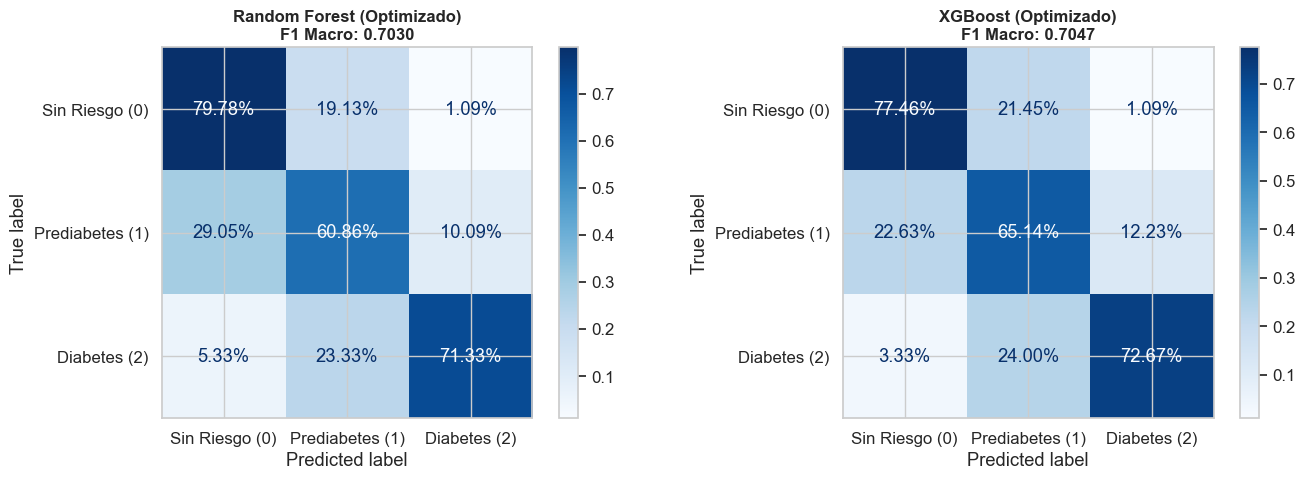

In [11]:
# Matrices de confusión lado a lado
plot_confusion_matrices([rf_results, xgb_results], y_test)

In [12]:
# Tabla comparativa de F1 por clase
print('=' * 70)
print('COMPARACIÓN FINAL DE MODELOS')
print('=' * 70)
print(f'{"Métrica":<30} {"RF Optimizado":>15} {"XGBoost":>15}')
print('-' * 70)

# Extraer F1 por clase de cada modelo
from sklearn.metrics import f1_score as f1_calc

for cls_idx, cls_name in LABELS_MAP.items():
    f1_rf = f1_calc(y_test, rf_results['y_pred'], average=None)[cls_idx]
    f1_xgb = f1_calc(y_test_encoded, xgb_results['y_pred'], average=None)[cls_idx]
    winner = '◄' if f1_xgb > f1_rf else ('◄' if f1_rf > f1_xgb else '')
    # Determine which is better
    rf_marker = ' ◄' if f1_rf > f1_xgb else ''
    xgb_marker = ' ◄' if f1_xgb > f1_rf else ''
    print(f'F1 Clase {cls_idx} ({cls_name:>12}):  {f1_rf:>12.4f}{rf_marker}  {f1_xgb:>12.4f}{xgb_marker}')

print('-' * 70)
rf_m = ' ◄' if rf_results['f1_macro'] > xgb_results['f1_macro'] else ''
xgb_m = ' ◄' if xgb_results['f1_macro'] > rf_results['f1_macro'] else ''
print(f'{"F1 Macro (GLOBAL)":<30} {rf_results["f1_macro"]:>12.4f}{rf_m}  {xgb_results["f1_macro"]:>12.4f}{xgb_m}')

rf_w = ' ◄' if rf_results['f1_weighted'] > xgb_results['f1_weighted'] else ''
xgb_w = ' ◄' if xgb_results['f1_weighted'] > rf_results['f1_weighted'] else ''
print(f'{"F1 Weighted":<30} {rf_results["f1_weighted"]:>12.4f}{rf_w}  {xgb_results["f1_weighted"]:>12.4f}{xgb_w}')
print('=' * 70)

# Conclusión automática
if xgb_results['f1_macro'] > rf_results['f1_macro']:
    best = 'XGBoost'
    delta = xgb_results['f1_macro'] - rf_results['f1_macro']
else:
    best = 'Random Forest Optimizado'
    delta = rf_results['f1_macro'] - xgb_results['f1_macro']

print(f'\n🏆 Mejor modelo: {best} (F1 Macro +{delta:.4f} sobre el competidor)')

COMPARACIÓN FINAL DE MODELOS
Métrica                          RF Optimizado         XGBoost
----------------------------------------------------------------------
F1 Clase 0 (  Sin Riesgo):        0.8231 ◄        0.8229
F1 Clase 1 ( Prediabetes):        0.5678        0.5812 ◄
F1 Clase 2 (    Diabetes):        0.7181 ◄        0.7101
----------------------------------------------------------------------
F1 Macro (GLOBAL)                    0.7030        0.7047 ◄
F1 Weighted                          0.7410        0.7435 ◄

🏆 Mejor modelo: XGBoost (F1 Macro +0.0017 sobre el competidor)


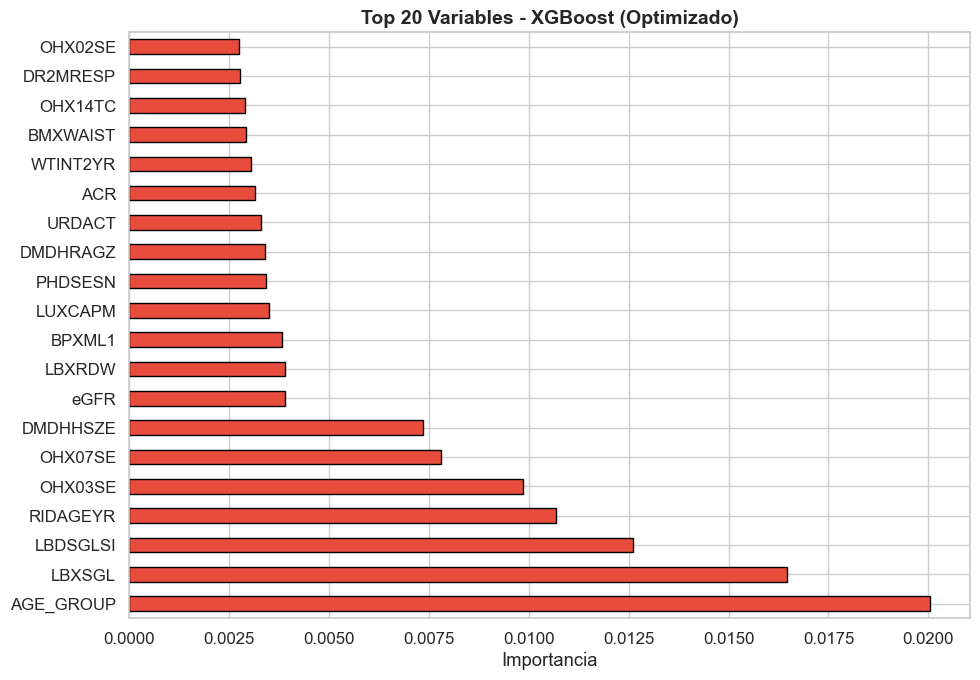


Top 20 features (XGBoost (Optimizado)):
  AGE_GROUP............................... 0.0201
  LBXSGL.................................. 0.0165
  LBDSGLSI................................ 0.0126
  RIDAGEYR................................ 0.0107
  OHX03SE................................. 0.0099
  OHX07SE................................. 0.0078
  DMDHHSZE................................ 0.0074
  eGFR.................................... 0.0039
  LBXRDW.................................. 0.0039
  BPXML1.................................. 0.0038
  LUXCAPM................................. 0.0035
  PHDSESN................................. 0.0034
  DMDHRAGZ................................ 0.0034
  URDACT.................................. 0.0033
  ACR..................................... 0.0032
  WTINT2YR................................ 0.0030
  BMXWAIST................................ 0.0029
  OHX14TC................................. 0.0029
  DR2MRESP................................ 0.0028
  OHX02SE

In [13]:
# Feature Importance del mejor modelo
if xgb_results['f1_macro'] >= rf_results['f1_macro']:
    best_model = xgb_search.best_estimator_
    best_name = 'XGBoost (Optimizado)'
    clf = best_model.named_steps['classifier']
    importances_raw = clf.feature_importances_
else:
    best_model = rf_search.best_estimator_
    best_name = 'Random Forest (Optimizado)'
    clf = best_model.named_steps['classifier']
    importances_raw = clf.feature_importances_

# Reconstruir nombres de features
feature_names_out = numeric_cols.copy()
if categorical_cols:
    feature_names_out += categorical_cols

importances = pd.Series(importances_raw, index=feature_names_out).sort_values(ascending=False)

top_n = 20
top_features = importances.head(top_n)

fig, ax = plt.subplots(figsize=(10, 7))
top_features.sort_values().plot(
    kind='barh', color='#e74c3c', edgecolor='black', ax=ax
)
ax.set_xlabel('Importancia')
ax.set_title(f'Top {top_n} Variables - {best_name}', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f'\nTop {top_n} features ({best_name}):')
for feat, imp in top_features.items():
    print(f'  {feat:.<40} {imp:.4f}')

---
## 6. Predicción Dual con el Mejor Modelo

In [14]:
# Usar el mejor modelo para demostración de predicción dual
if xgb_results['f1_macro'] >= rf_results['f1_macro']:
    demo_model = xgb_search.best_estimator_
    demo_name = 'XGBoost'
    demo_y_pred = xgb_results['y_pred']
    demo_y_proba = xgb_results['y_proba']
    demo_y_test = y_test_encoded
else:
    demo_model = rf_search.best_estimator_
    demo_name = 'Random Forest'
    demo_y_pred = rf_results['y_pred']
    demo_y_proba = rf_results['y_proba']
    demo_y_test = y_test.values

# Ejemplo con 8 pacientes aleatorios
np.random.seed(RANDOM_STATE)
sample_indices = np.random.choice(len(X_test), size=8, replace=False)

print('=' * 75)
print(f'PREDICCIÓN DUAL - {demo_name} (Optimizado)')
print('=' * 75)

aciertos = 0
for i, idx in enumerate(sample_indices):
    clase_real = int(demo_y_test[idx]) if isinstance(demo_y_test, np.ndarray) else int(demo_y_test.iloc[idx])
    clase_pred = int(demo_y_pred[idx])
    probs = demo_y_proba[idx]
    
    correcto = clase_real == clase_pred
    if correcto:
        aciertos += 1
    
    print(f'\n--- Paciente {i+1} ---')
    print(f'  Clase Real:      {clase_real} ({LABELS_MAP[clase_real]})')
    print(f'  Clase Predicha:  {clase_pred} ({LABELS_MAP[clase_pred]})')
    print(f'  Probabilidades:')
    for cls_idx, prob in enumerate(probs):
        marker = ' ◄' if cls_idx == clase_pred else ''
        print(f'    Clase {cls_idx} ({LABELS_MAP[cls_idx]:>12}): {prob*100:6.2f}%{marker}')
    
    resultado = '✅ CORRECTO' if correcto else '❌ INCORRECTO'
    print(f'  Resultado: {resultado}')

print(f'\nPrecisión en muestra: {aciertos}/{len(sample_indices)} ({aciertos/len(sample_indices)*100:.0f}%)')
print('=' * 75)

PREDICCIÓN DUAL - XGBoost (Optimizado)

--- Paciente 1 ---
  Clase Real:      1 (Prediabetes)
  Clase Predicha:  1 (Prediabetes)
  Probabilidades:
    Clase 0 (  Sin Riesgo):  17.08%
    Clase 1 ( Prediabetes):  48.80% ◄
    Clase 2 (    Diabetes):  34.11%
  Resultado: ✅ CORRECTO

--- Paciente 2 ---
  Clase Real:      1 (Prediabetes)
  Clase Predicha:  0 (Sin Riesgo)
  Probabilidades:
    Clase 0 (  Sin Riesgo):  55.47% ◄
    Clase 1 ( Prediabetes):  41.95%
    Clase 2 (    Diabetes):   2.58%
  Resultado: ❌ INCORRECTO

--- Paciente 3 ---
  Clase Real:      0 (Sin Riesgo)
  Clase Predicha:  0 (Sin Riesgo)
  Probabilidades:
    Clase 0 (  Sin Riesgo):  89.76% ◄
    Clase 1 ( Prediabetes):   9.35%
    Clase 2 (    Diabetes):   0.90%
  Resultado: ✅ CORRECTO

--- Paciente 4 ---
  Clase Real:      0 (Sin Riesgo)
  Clase Predicha:  1 (Prediabetes)
  Probabilidades:
    Clase 0 (  Sin Riesgo):  36.92%
    Clase 1 ( Prediabetes):  50.45% ◄
    Clase 2 (    Diabetes):  12.64%
  Resultado: ❌ INCO

---
## 7. Resumen y Conclusiones

### ¿Qué hicimos en esta fase?
1. **Optimizamos el Random Forest** con `RandomizedSearchCV` (40 combinaciones × 5 folds = 200 fits).
2. **Entrenamos y optimizamos XGBoost** (50 combinaciones × 5 folds = 250 fits), con `sample_weight` balanceado para compensar el desbalance de clases.
3. **Comparamos ambos modelos** en F1 Macro, F1 por clase y matrices de confusión.

### Claves de la optimización
- **Métrica de optimización**: F1 Macro, que penaliza fuertemente si el modelo falla en la clase minoritaria.
- **Desbalance**: Tratado con `class_weight='balanced'` (RF) y `sample_weight` (XGBoost).
- **Validación**: Cross-Validation 5-Fold estratificado, más evaluación final en test set separado.

### Próximos pasos
- Análisis de errores más profundo.
- Posible threshold tuning para la clase Prediabetes.
- Serialización del mejor modelo con `joblib` para uso en producción.